# **Imports & Setup**

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

os.makedirs('/kaggle/working/visualizations', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)

RANDOM_STATE = 20
plt.style.use('seaborn-v0_8-whitegrid')

# **Load Dataset**

In [17]:
df = pd.read_csv('/kaggle/input/datasets/sharadhiv/indian-liver-patient-dataset-ilpd/Indian Liver Patient Dataset (ILPD).csv')

# If your file is a CSV instead, use:
# df = pd.read_csv('/kaggle/input/your-dataset-folder/ILPD_final_same_format.csv')

print('Shape:', df.shape)
print(df.dtypes)
df.head()

Shape: (583, 11)
age                   int64
gender               object
tot_bilirubin       float64
direct_bilirubin    float64
tot_proteins          int64
albumin               int64
ag_ratio              int64
sgpt                float64
sgot                float64
alkphos             float64
is_patient            int64
dtype: object


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [18]:
dup_mask = df.duplicated(keep=False)
duplicate_rows = df[dup_mask].sort_values(by=df.columns.tolist())

print(f'Total duplicate rows (both copies counted): {dup_mask.sum()}')
print(f'Rows that will be dropped (keeping first): {df.duplicated(keep="first").sum()}')
print()
duplicate_rows

Total duplicate rows (both copies counted): 26
Rows that will be dropped (keeping first): 13



,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
137,18,Male,0.8,0.2,282,72,140,5.5,2.5,0.80,1
138,18,Male,0.8,0.2,282,72,140,5.5,2.5,0.80,1
142,30,Male,1.6,0.4,332,84,139,5.6,2.7,0.90,1
143,30,Male,1.6,0.4,332,84,139,5.6,2.7,0.90,1
173,31,Male,0.6,0.1,175,48,34,6.0,3.7,1.60,1
174,31,Male,0.6,0.1,175,48,34,6.0,3.7,1.60,1
25,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,1
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,1
107,36,Male,0.8,0.2,158,29,39,6.0,2.2,0.50,2
108,36,Male,0.8,0.2,158,29,39,6.0,2.2,0.50,2


In [19]:
print('Null counts:')
print(df.isnull().sum())

# Impute alkphos (4 missing values) with median
df['alkphos'] = df['alkphos'].fillna(df['alkphos'].median())

print('\nNull counts after imputation:')
print(df.isnull().sum())

Null counts:
age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             4
is_patient          0
dtype: int64

Null counts after imputation:
age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             0
is_patient          0
dtype: int64


# **Encode & Preprocess** 

In [20]:
# FIX: Original code ran LabelEncoder on ALL columns including numerics — wrong.
# Only encode the single string column: gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])  # Female=0, Male=1

# Remap target: 1 = liver patient, 2 = healthy → binary 1/0
df['is_patient'] = df['is_patient'].map({1: 1, 2: 0})

print('Target distribution after remapping:')
print(df['is_patient'].value_counts())
print('  1 = Liver Patient | 0 = Healthy')

Target distribution after remapping:
is_patient
1    416
0    167
Name: count, dtype: int64
  1 = Liver Patient | 0 = Healthy


# **Feature Split, Scale, Train/Test Split, SMOTE**

In [21]:
X = df.drop('is_patient', axis=1)
y = df['is_patient']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, '/kaggle/working/models/scaler.pkl')

# stratify=y ensures class balance is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# SMOTE on training split only — never on test data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('After SMOTE y_train:', pd.Series(y_train_sm).value_counts().to_dict())

# SMOTE on training only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print('\nTest set (untouched):')
print(y_test.value_counts())

X_train: (466, 10) | X_test: (117, 10)
After SMOTE y_train: {0: 333, 1: 333}

After SMOTE:
is_patient
0    333
1    333
Name: count, dtype: int64

Test set (untouched):
is_patient
1    83
0    34
Name: count, dtype: int64


# **Dataset Visualizations**

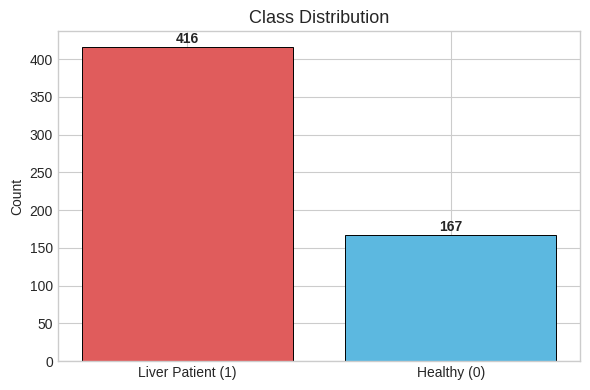

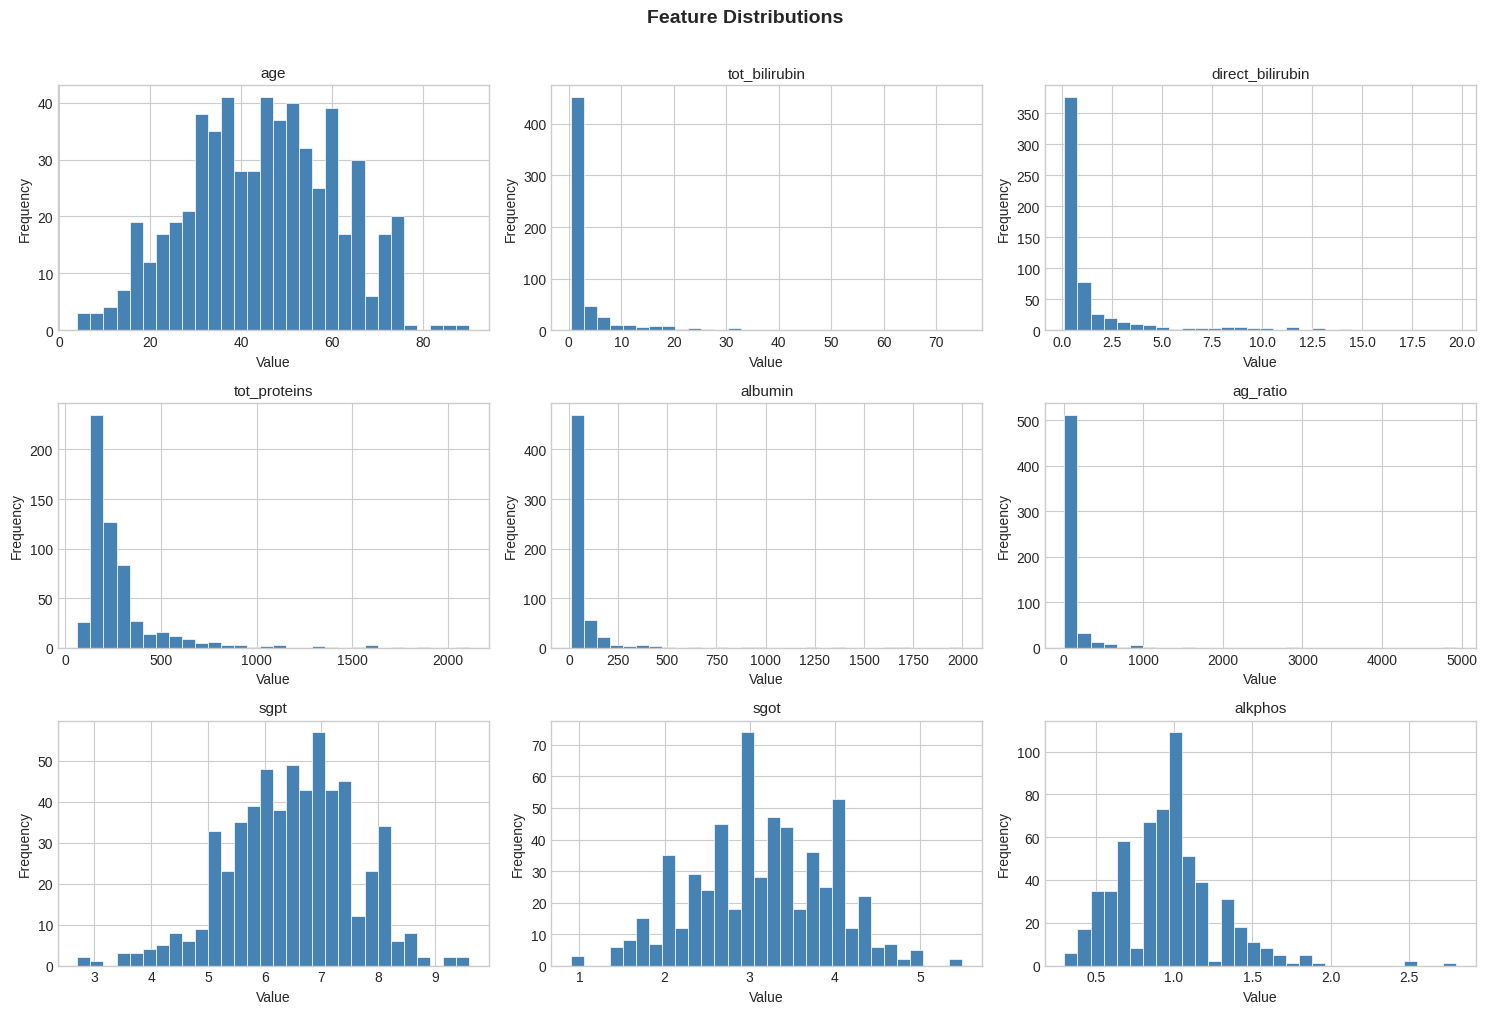

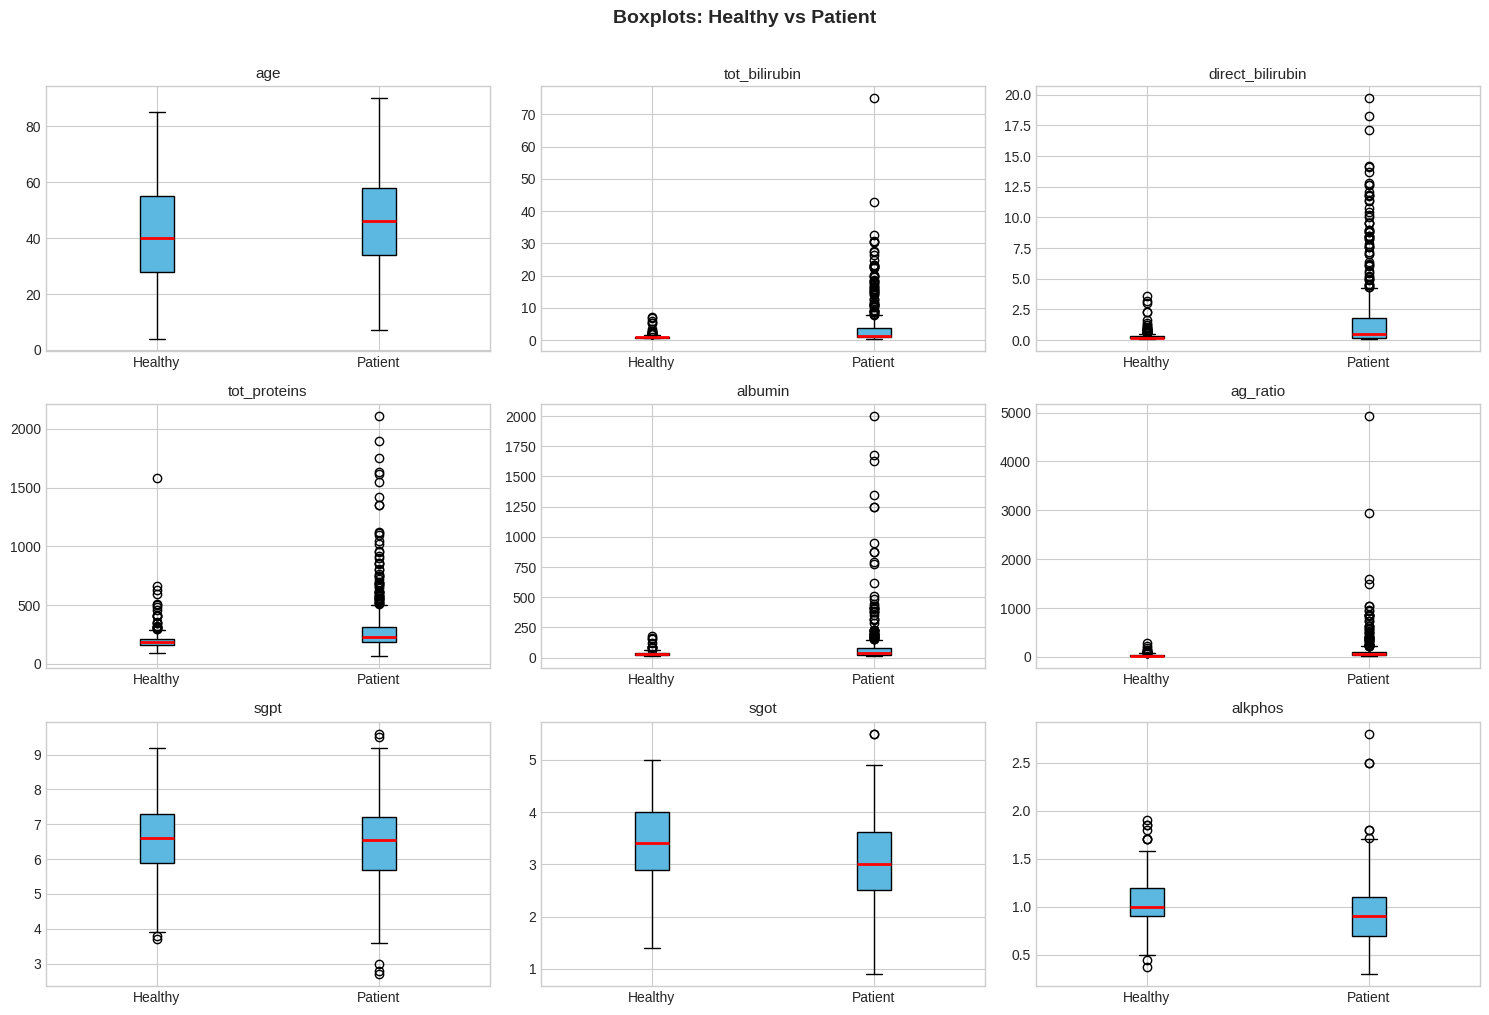

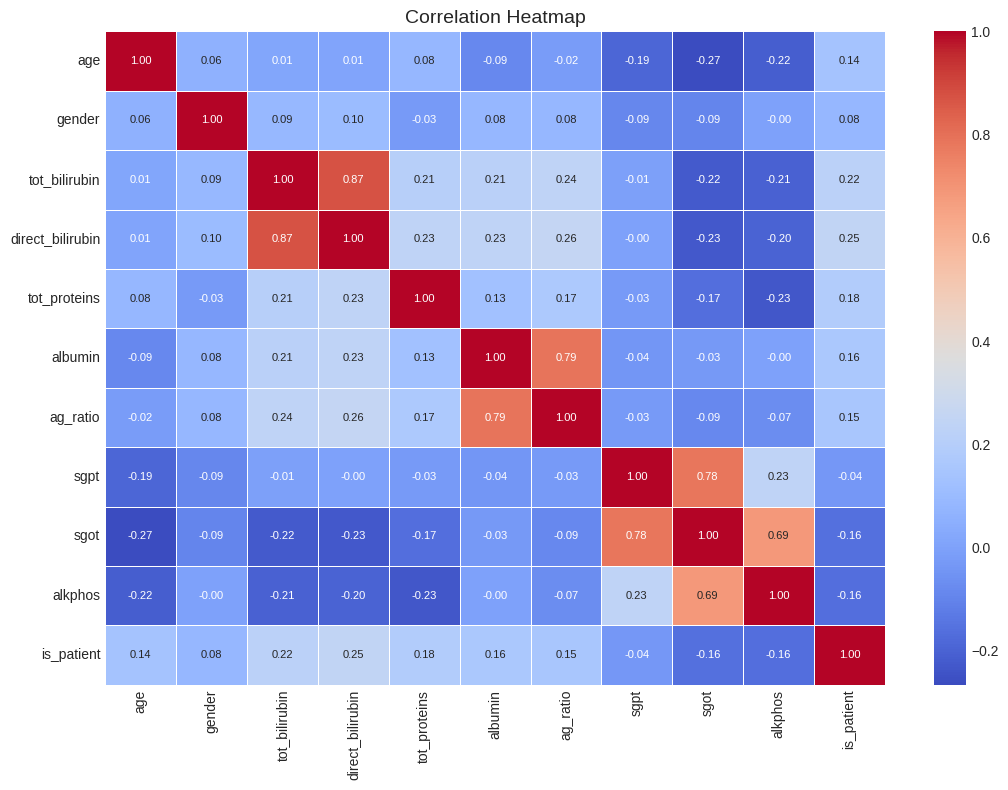

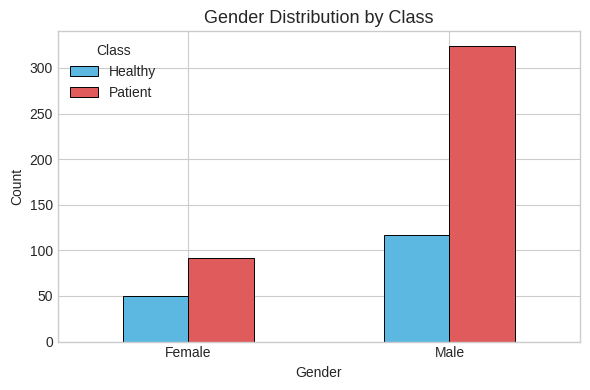

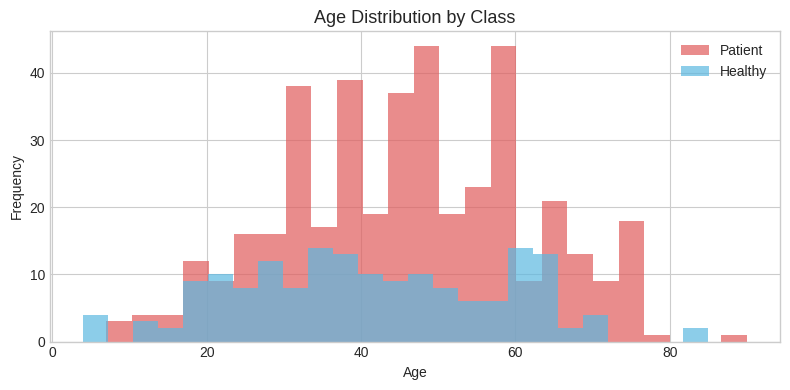

In [22]:
num_cols = [c for c in df.columns if c not in ['is_patient', 'gender']]

# 1. Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['is_patient'].value_counts()
ax.bar(['Liver Patient (1)', 'Healthy (0)'], counts.values,
       color=['#e05c5c', '#5cb8e0'], edgecolor='black', linewidth=0.7)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Class Distribution', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/01_class_distribution.png', dpi=150)
plt.show()

# 2. Feature Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Boxplots: Healthy vs Patient
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    d0 = df.loc[df['is_patient'] == 0, col].dropna()
    d1 = df.loc[df['is_patient'] == 1, col].dropna()
    axes[i].boxplot([d0, d1], labels=['Healthy', 'Patient'], patch_artist=True,
                    boxprops=dict(facecolor='#5cb8e0'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots: Healthy vs Patient', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/03_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Correlation Heatmap
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/04_correlation_heatmap.png', dpi=150)
plt.show()

# 5. Gender by Class
fig, ax = plt.subplots(figsize=(6, 4))
gdf = df.groupby(['gender', 'is_patient']).size().unstack(fill_value=0)
gdf.index = ['Female', 'Male']
gdf.columns = ['Healthy', 'Patient']
gdf.plot(kind='bar', ax=ax, color=['#5cb8e0', '#e05c5c'],
         edgecolor='black', linewidth=0.7, rot=0)
ax.set_title('Gender Distribution by Class', fontsize=13)
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.legend(title='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/05_gender_by_class.png', dpi=150)
plt.show()

# 6. Age Distribution by Class
fig, ax = plt.subplots(figsize=(8, 4))
df[df['is_patient'] == 1]['age'].hist(bins=25, alpha=0.7, label='Patient', color='#e05c5c', ax=ax)
df[df['is_patient'] == 0]['age'].hist(bins=25, alpha=0.7, label='Healthy', color='#5cb8e0', ax=ax)
ax.set_title('Age Distribution by Class', fontsize=13)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/06_age_distribution_by_class.png', dpi=150)
plt.show()

# **Train All Models**

In [23]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)
    test_acc  = accuracy_score(y_te, y_pred)
    train_acc = accuracy_score(y_tr, y_pred_tr)

    unique_preds = pd.Series(y_pred).value_counts().to_dict()
    n_classes_predicted = len(unique_preds)

    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model,
        'y_pred': y_pred,
        'predicts_both_classes': n_classes_predicted == 2
    }

    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(model, f'/kaggle/working/models/{safe_name}.pkl')

    print(f'\n── {name}')
    print(f'   Train Acc : {train_acc:.4f} | Test Acc: {test_acc:.4f}')
    print(f'   Predicted : {unique_preds}', '  ⚠ DEGENERATE' if n_classes_predicted < 2 else '')
    print(classification_report(y_te, y_pred, target_names=['Healthy(0)', 'Patient(1)']))
    return model

# Linear models: use class_weight instead of SMOTE data
# (they respond better to weighting than to synthetic oversampling)
lr = evaluate_model('Logistic Regression',
                    LogisticRegression(max_iter=1000, class_weight='balanced',
                                       C=0.1, random_state=RANDOM_STATE),
                    X_train_scaled, y_train, X_test_scaled, y_test)

svm_lin = evaluate_model('SVM Linear',
                          SVC(kernel='linear', probability=True, class_weight='balanced',
                              C=0.1, random_state=RANDOM_STATE),
                          X_train_scaled, y_train, X_test_scaled, y_test)

# Kernel SVMs: use SMOTE data, no class_weight
svm_rbf = evaluate_model('SVM RBF',
                          SVC(kernel='rbf', probability=True, C=1, gamma='scale',
                              random_state=RANDOM_STATE),
                          X_train_sm, y_train_sm, X_test_scaled, y_test)

svm_poly = evaluate_model('SVM Poly',
                           SVC(kernel='poly', probability=True, C=1,
                               random_state=RANDOM_STATE),
                           X_train_sm, y_train_sm, X_test_scaled, y_test)

knn = evaluate_model('KNN',
                     KNeighborsClassifier(n_neighbors=7),
                     X_train_sm, y_train_sm, X_test_scaled, y_test)

# Tree models: use class_weight + constrain depth to prevent overfitting
dt = evaluate_model('Decision Tree',
                    DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                           class_weight='balanced', random_state=RANDOM_STATE),
                    X_train_scaled, y_train, X_test_scaled, y_test)

rf = evaluate_model('Random Forest',
                    RandomForestClassifier(n_estimators=200, max_depth=8,
                                           min_samples_leaf=5, class_weight='balanced',
                                           random_state=RANDOM_STATE),
                    X_train_scaled, y_train, X_test_scaled, y_test)

# Boosting models: use scale_pos_weight to handle imbalance, no SMOTE
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos  # scale_pos_weight = count(negative) / count(positive)
print(f'XGBoost scale_pos_weight: {spw:.3f}')

ada = evaluate_model('AdaBoost',
                     AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                                        random_state=RANDOM_STATE),
                     X_train_sm, y_train_sm, X_test_scaled, y_test)

gb = evaluate_model('Gradient Boosting',
                    GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                               learning_rate=0.05, subsample=0.8,
                                               random_state=RANDOM_STATE),
                    X_train_sm, y_train_sm, X_test_scaled, y_test)

xgb = evaluate_model('XGBoost',
                     XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8,
                                   scale_pos_weight=spw, eval_metric='logloss',
                                   use_label_encoder=False, random_state=RANDOM_STATE),
                     X_train_scaled, y_train, X_test_scaled, y_test)


── Logistic Regression
   Train Acc : 0.6180 | Test Acc: 0.5897
   Predicted : {1: 59, 0: 58} 
              precision    recall  f1-score   support

  Healthy(0)       0.38      0.65      0.48        34
  Patient(1)       0.80      0.57      0.66        83

    accuracy                           0.59       117
   macro avg       0.59      0.61      0.57       117
weighted avg       0.68      0.59      0.61       117


── SVM Linear
   Train Acc : 0.5858 | Test Acc: 0.5641
   Predicted : {0: 71, 1: 46} 
              precision    recall  f1-score   support

  Healthy(0)       0.38      0.79      0.51        34
  Patient(1)       0.85      0.47      0.60        83

    accuracy                           0.56       117
   macro avg       0.61      0.63      0.56       117
weighted avg       0.71      0.56      0.58       117


── SVM RBF
   Train Acc : 0.7192 | Test Acc: 0.6154
   Predicted : {0: 71, 1: 46} 
              precision    recall  f1-score   support

  Healthy(0)       0.42 

# **Hyperparameter Tuning**

In [24]:
# Grid Search
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 'auto']}
grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_sm, y_train_sm)
print('Grid Search Best Params:', grid.best_params_)
print('Grid Search Best CV Score:', round(grid.best_score_, 4))
print('Grid Search Test Accuracy:', round(accuracy_score(y_test, grid.predict(X_test)), 4))
joblib.dump(grid.best_estimator_, '/kaggle/working/models/SVM_GridSearch_Best.pkl')

# Random Search
param_dist = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 'auto']}
rand_search = RandomizedSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                                 param_distributions=param_dist, n_iter=5, cv=5,
                                 scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
rand_search.fit(X_train_sm, y_train_sm)
print('\nRandom Search Best Params:', rand_search.best_params_)
print('Random Search Best CV Score:', round(rand_search.best_score_, 4))
print('Random Search Test Accuracy:', round(accuracy_score(y_test, rand_search.predict(X_test)), 4))
joblib.dump(rand_search.best_estimator_, '/kaggle/working/models/SVM_RandomSearch_Best.pkl')

Grid Search Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Grid Search Best CV Score: 0.7163
Grid Search Test Accuracy: 0.6325

Random Search Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 100}
Random Search Best CV Score: 0.7193
Random Search Test Accuracy: 0.641


['/kaggle/working/models/SVM_RandomSearch_Best.pkl']

# **KFold Cross Validation**

In [25]:
X_all_sm, y_all_sm = SMOTE(random_state=RANDOM_STATE).fit_resample(X_scaled, y)
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kfold_accs = []

for fold, (tr_idx, te_idx) in enumerate(kfold.split(X_all_sm), 1):
    m = SVC(random_state=RANDOM_STATE)
    m.fit(X_all_sm[tr_idx], y_all_sm[tr_idx])
    acc = accuracy_score(y_all_sm[te_idx], m.predict(X_all_sm[te_idx]))
    kfold_accs.append(acc)
    print(f'Fold {fold} Accuracy: {acc:.4f}')

print(f'\nMean KFold Accuracy: {np.mean(kfold_accs):.4f} ± {np.std(kfold_accs):.4f}')

Fold 1 Accuracy: 0.6766
Fold 2 Accuracy: 0.7126
Fold 3 Accuracy: 0.6988
Fold 4 Accuracy: 0.6566
Fold 5 Accuracy: 0.7229

Mean KFold Accuracy: 0.6935 ± 0.0241


# **Bootsrap**

In [26]:
bootstrap_accs = []
for i in range(50):
    Xb, yb = resample(X_all_sm, y_all_sm, replace=True, random_state=i)
    Xbtr, Xbte, ybtr, ybte = train_test_split(Xb, yb, test_size=0.3, random_state=i)
    m = SVC(random_state=RANDOM_STATE)
    m.fit(Xbtr, ybtr)
    bootstrap_accs.append(accuracy_score(ybte, m.predict(Xbte)))

print(f'Bootstrap Mean Accuracy (50 iters): {np.mean(bootstrap_accs):.4f} ± {np.std(bootstrap_accs):.4f}')

Bootstrap Mean Accuracy (50 iters): 0.6952 ± 0.0336


# **PCA**

In [27]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
joblib.dump(pca, '/kaggle/working/models/pca.pkl')

print('Explained Variance Ratio (5 components):')
for i, v in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {v:.4f}  ({v*100:.2f}%)')
print(f'  Total: {pca.explained_variance_ratio_.sum():.4f}')

Explained Variance Ratio (5 components):
  PC1: 0.5463  (54.63%)
  PC2: 0.1756  (17.56%)
  PC3: 0.0903  (9.03%)
  PC4: 0.0737  (7.37%)
  PC5: 0.0416  (4.16%)
  Total: 0.9275


# **Model Performance Visualizations**

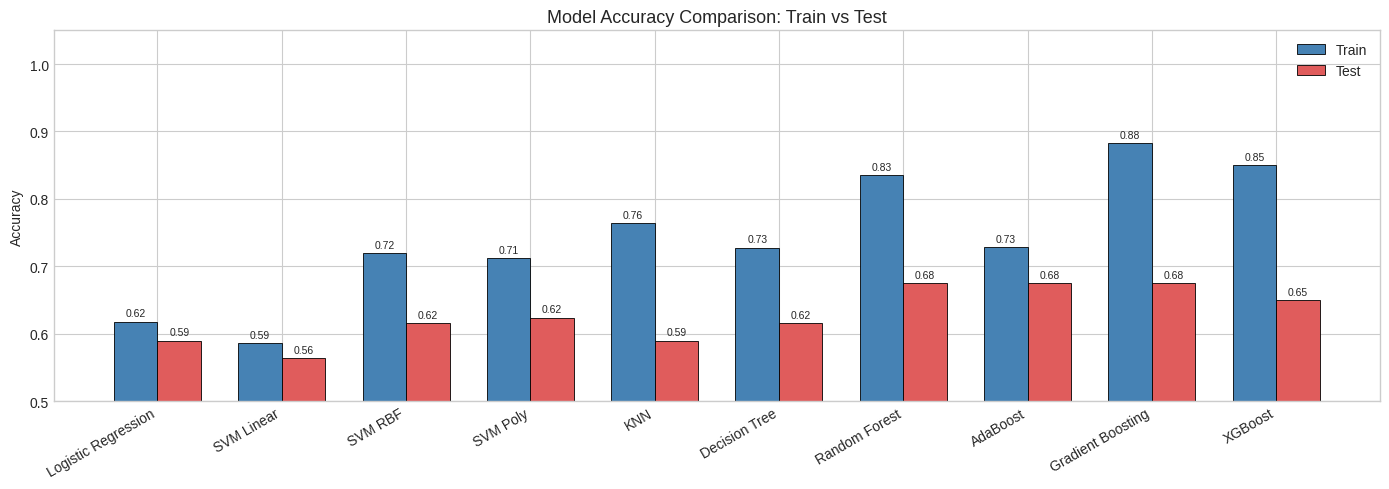

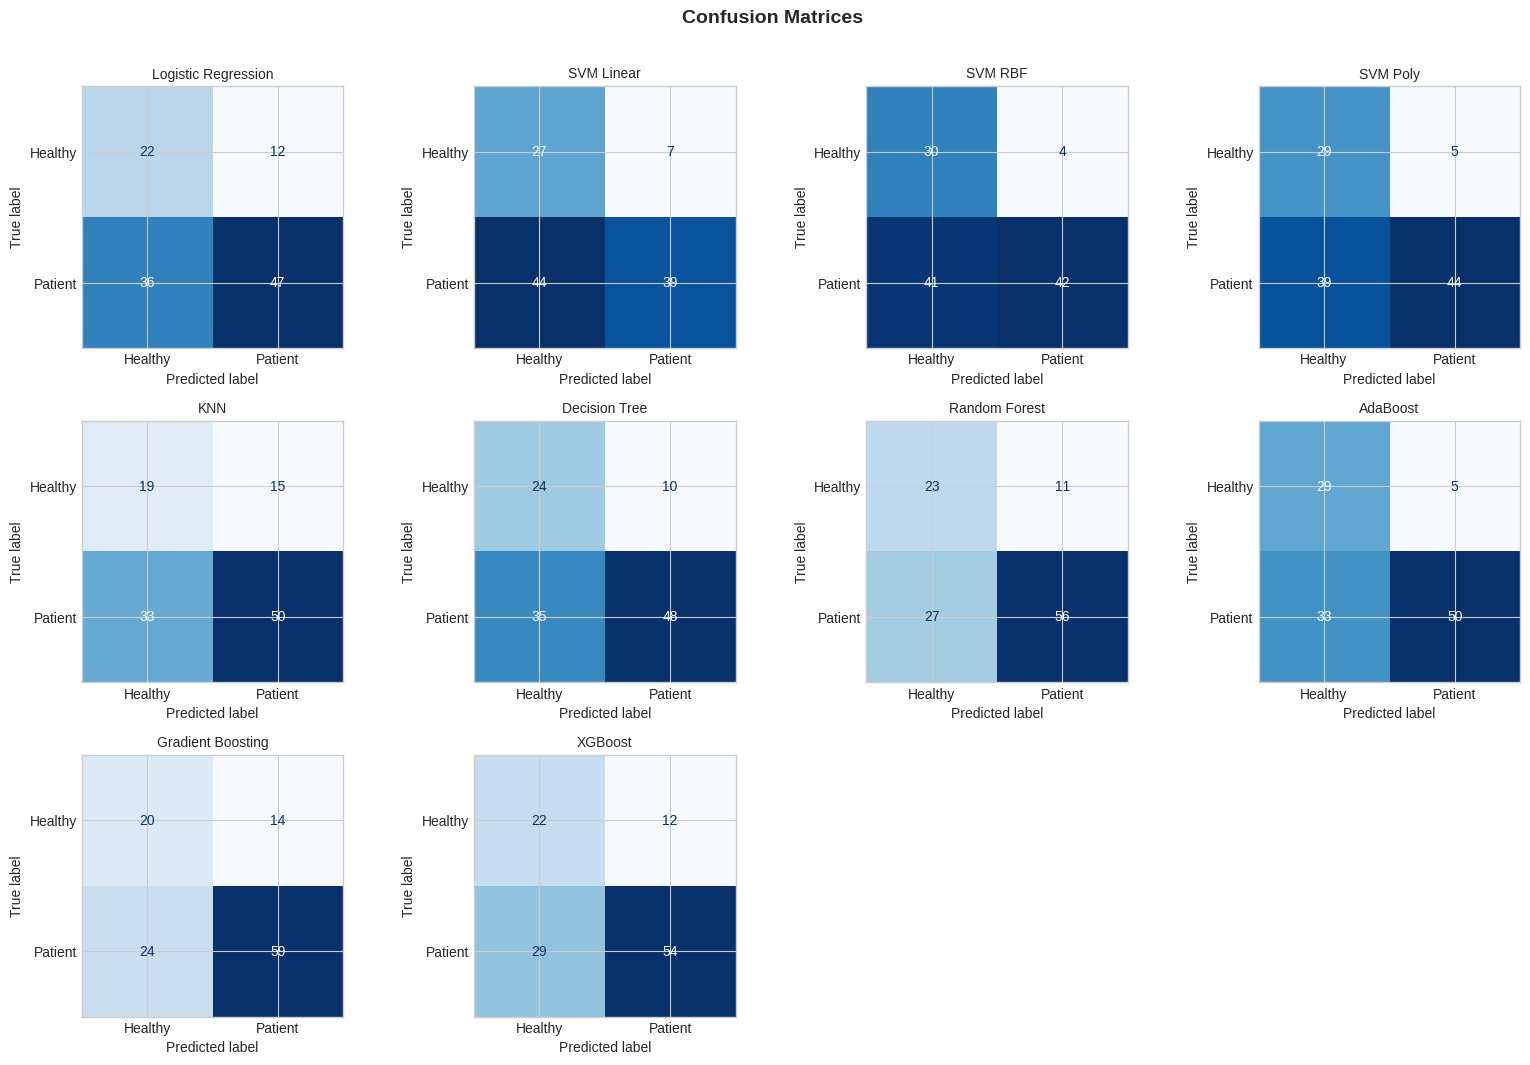

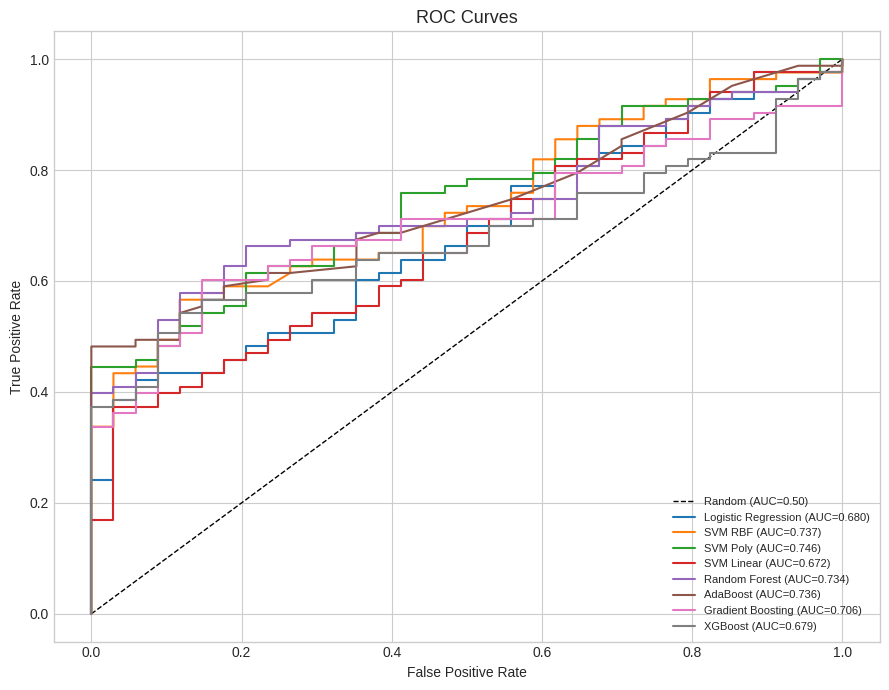

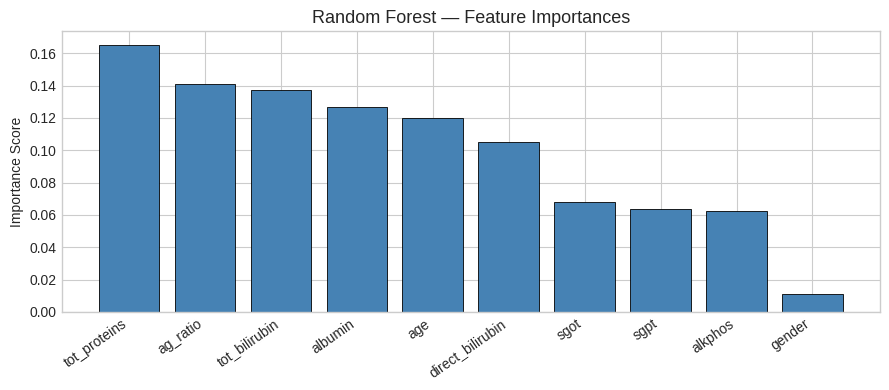

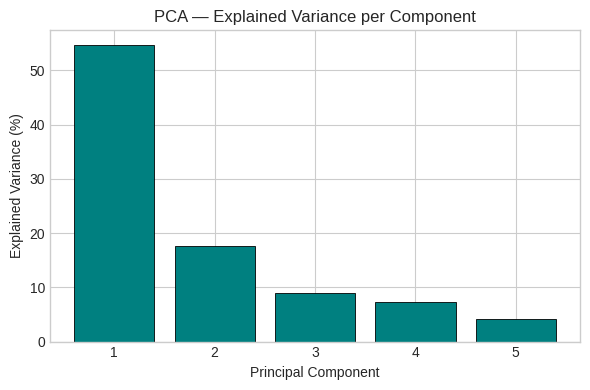

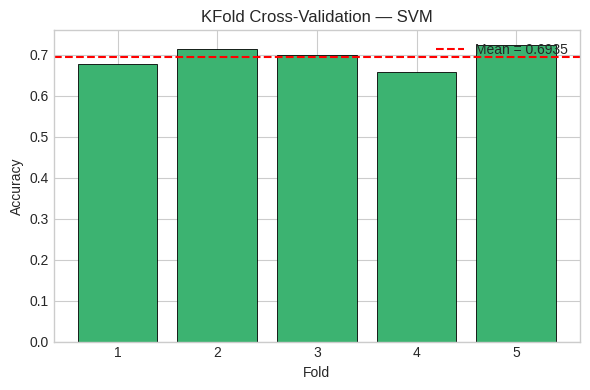

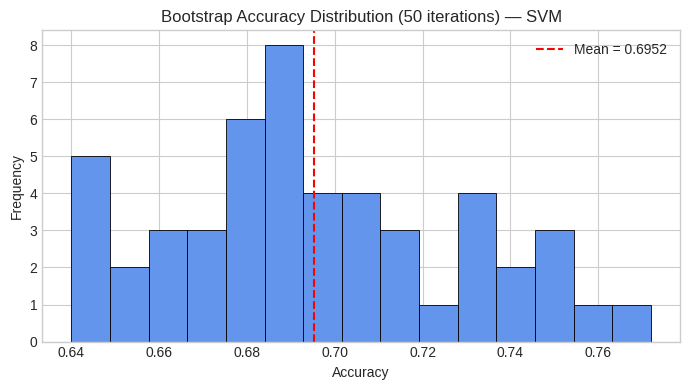

In [28]:
model_names = list(results.keys())
train_accs  = [results[m]['train_acc'] for m in model_names]
test_accs   = [results[m]['test_acc']  for m in model_names]

# 7. Train vs Test Accuracy Bar Chart
x_pos = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x_pos - width/2, train_accs, width, label='Train', color='steelblue', edgecolor='black', linewidth=0.6)
b2 = ax.bar(x_pos + width/2, test_accs,  width, label='Test',  color='#e05c5c',  edgecolor='black', linewidth=0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison: Train vs Test', fontsize=13)
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/07_model_accuracy_comparison.png', dpi=150)
plt.show()

# 8. Confusion Matrices
cols_cm = 4
rows_cm = (len(results) + cols_cm - 1) // cols_cm
fig, axes = plt.subplots(rows_cm, cols_cm, figsize=(cols_cm * 4, rows_cm * 3.5))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Patient']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. ROC Curves
prob_models = {
    'Logistic Regression': lr, 'SVM RBF': svm_rbf, 'SVM Poly': svm_poly,
    'SVM Linear': svm_lin, 'Random Forest': rf, 'AdaBoost': ada,
    'Gradient Boosting': gb, 'XGBoost': xgb
}
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.50)')
for name, model in prob_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=1.5, label=f'{name} (AUC={auc:.3f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/09_roc_curves.png', dpi=150)
plt.show()

# 10. Feature Importances (Random Forest)
feat_names   = df.drop('is_patient', axis=1).columns.tolist()
importances  = rf.feature_importances_
sorted_idx   = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(feat_names)), importances[sorted_idx],
       color='steelblue', edgecolor='black', linewidth=0.6)
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in sorted_idx], rotation=35, ha='right')
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/10_feature_importances_rf.png', dpi=150)
plt.show()

# 11. PCA Explained Variance
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 6), pca.explained_variance_ratio_ * 100,
       color='teal', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA — Explained Variance per Component', fontsize=12)
ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/11_pca_explained_variance.png', dpi=150)
plt.show()

# 12. KFold Accuracy per Fold
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 6), kfold_accs, color='mediumseagreen', edgecolor='black', linewidth=0.6)
ax.axhline(np.mean(kfold_accs), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(kfold_accs):.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('KFold Cross-Validation — SVM', fontsize=12)
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/12_kfold_accuracy.png', dpi=150)
plt.show()

# 13. Bootstrap Accuracy Distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bootstrap_accs, bins=15, color='cornflowerblue', edgecolor='black', linewidth=0.6)
ax.axvline(np.mean(bootstrap_accs), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(bootstrap_accs):.4f}')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Accuracy Distribution (50 iterations) — SVM', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/13_bootstrap_accuracy.png', dpi=150)
plt.show()

# **Summary table**

In [29]:
summary = pd.DataFrame({
    'Model':           model_names,
    'Train Acc':       [round(results[m]['train_acc'], 4) for m in model_names],
    'Test Acc':        [round(results[m]['test_acc'],  4) for m in model_names],
    'Predicts Both':   [results[m]['predicts_both_classes'] for m in model_names],
}).sort_values('Test Acc', ascending=False).reset_index(drop=True)

majority_baseline = y_test.value_counts(normalize=True).max()
print(f'Majority class baseline: {majority_baseline:.4f}')
print()
summary

Majority class baseline: 0.7094



,Model,Train Acc,Test Acc,Predicts Both
0,Gradient Boosting,0.8829,0.6752,True
1,AdaBoost,0.7282,0.6752,True
2,Random Forest,0.8348,0.6752,True
3,XGBoost,0.8498,0.6496,True
4,SVM Poly,0.7117,0.6239,True
5,SVM RBF,0.7192,0.6154,True
6,Decision Tree,0.7275,0.6154,True
7,Logistic Regression,0.6180,0.5897,True
8,KNN,0.7643,0.5897,True
9,SVM Linear,0.5858,0.5641,True


In [30]:
for name, res in results.items():
    unique_preds = pd.Series(res['y_pred']).value_counts().to_dict()
    print(f'{name}: predicted classes → {unique_preds}')

Logistic Regression: predicted classes → {1: 59, 0: 58}
SVM Linear: predicted classes → {0: 71, 1: 46}
SVM RBF: predicted classes → {0: 71, 1: 46}
SVM Poly: predicted classes → {0: 68, 1: 49}
KNN: predicted classes → {1: 65, 0: 52}
Decision Tree: predicted classes → {0: 59, 1: 58}
Random Forest: predicted classes → {1: 67, 0: 50}
AdaBoost: predicted classes → {0: 62, 1: 55}
Gradient Boosting: predicted classes → {1: 73, 0: 44}
XGBoost: predicted classes → {1: 66, 0: 51}


# **Sample Testing**

In [31]:
# ── Sample Test Cases
# Format: [age, gender(0=F,1=M), tot_bilirubin, direct_bilirubin, tot_proteins, albumin, ag_ratio, sgpt, sgot, alkphos]

samples = pd.DataFrame({
    'age':              [58,  34,  45,  29,  70],
    'gender':           [1,   0,   1,   0,   1],
    'tot_bilirubin':    [3.5, 0.7, 1.1, 0.5, 8.9],
    'direct_bilirubin': [1.8, 0.1, 0.3, 0.1, 4.5],
    'tot_proteins':     [290, 180, 210, 160, 310],
    'albumin':          [60,  30,  45,  25,  80],
    'ag_ratio':         [120, 40,  80,  30,  200],
    'sgpt':             [7.8, 4.2, 5.1, 3.8, 8.5],
    'sgot':             [4.5, 2.1, 2.8, 1.9, 5.0],
    'alkphos':          [1.8, 0.6, 0.9, 0.5, 2.1],
})

# Description of each sample for context
descriptions = [
    'Older male, elevated bilirubin and enzymes — likely patient',
    'Young female, normal values across the board — likely healthy',
    'Middle-aged male, borderline values — uncertain',
    'Young female, low-normal values — likely healthy',
    'Elderly male, severely elevated bilirubin and enzymes — likely patient',
]

# Scale using the fitted scaler
samples_scaled = scaler.transform(samples)

# Run through all trained models
model_objects = {
    'Logistic Regression': lr,
    'SVM RBF':             svm_rbf,
    'SVM Poly':            svm_poly,
    'SVM Linear':          svm_lin,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'AdaBoost':            ada,
    'Gradient Boosting':   gb,
    'XGBoost':             xgb,
}

# Build prediction table
pred_rows = []
for model_name, model in model_objects.items():
    preds = model.predict(samples_scaled)
    pred_rows.append([model_name] + ['Patient' if p == 1 else 'Healthy' for p in preds])

col_names = ['Model'] + [f'Sample {i+1}' for i in range(len(samples))]
pred_df = pd.DataFrame(pred_rows, columns=col_names)

print('Predictions (1=Patient, 0=Healthy)')
print()
pred_df

Predictions (1=Patient, 0=Healthy)



,Model,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5
0,Logistic Regression,Healthy,Healthy,Patient,Healthy,Healthy
1,SVM RBF,Healthy,Healthy,Healthy,Healthy,Patient
2,SVM Poly,Patient,Healthy,Healthy,Healthy,Patient
3,SVM Linear,Healthy,Healthy,Healthy,Healthy,Healthy
4,KNN,Healthy,Healthy,Healthy,Healthy,Healthy
5,Decision Tree,Patient,Healthy,Healthy,Healthy,Patient
6,Random Forest,Patient,Healthy,Patient,Healthy,Patient
7,AdaBoost,Patient,Healthy,Healthy,Healthy,Patient
8,Gradient Boosting,Patient,Healthy,Healthy,Healthy,Patient
9,XGBoost,Patient,Healthy,Patient,Healthy,Patient


In [32]:
# ── Agreement Summary — how many models agree per sample
print('Model Agreement per Sample:')
print()
for i in range(len(samples)):
    col = f'Sample {i+1}'
    counts = pred_df[col].value_counts().to_dict()
    patient_votes = counts.get('Patient', 0)
    healthy_votes = counts.get('Healthy', 0)
    verdict = 'Patient' if patient_votes > healthy_votes else 'Healthy'
    print(f'  Sample {i+1} | {descriptions[i]}')
    print(f'             Patient={patient_votes}/10  Healthy={healthy_votes}/10  → Majority: {verdict}')
    print()

Model Agreement per Sample:

  Sample 1 | Older male, elevated bilirubin and enzymes — likely patient
             Patient=6/10  Healthy=4/10  → Majority: Patient

  Sample 2 | Young female, normal values across the board — likely healthy
             Patient=0/10  Healthy=10/10  → Majority: Healthy

  Sample 3 | Middle-aged male, borderline values — uncertain
             Patient=3/10  Healthy=7/10  → Majority: Healthy

  Sample 4 | Young female, low-normal values — likely healthy
             Patient=0/10  Healthy=10/10  → Majority: Healthy

  Sample 5 | Elderly male, severely elevated bilirubin and enzymes — likely patient
             Patient=7/10  Healthy=3/10  → Majority: Patient



In [33]:
# ── Probability scores for models that support predict_proba
print('Patient Probability Scores (models with predict_proba):')
print()

prob_model_objects = {
    'Logistic Regression': lr,
    'SVM RBF':             svm_rbf,
    'SVM Poly':            svm_poly,
    'SVM Linear':          svm_lin,
    'Random Forest':       rf,
    'AdaBoost':            ada,
    'Gradient Boosting':   gb,
    'XGBoost':             xgb,
}

prob_rows = []
for model_name, model in prob_model_objects.items():
    probs = model.predict_proba(samples_scaled)[:, 1]  # probability of class 1 (Patient)
    prob_rows.append([model_name] + [round(p, 3) for p in probs])

prob_df = pd.DataFrame(prob_rows, columns=col_names)
prob_df

Patient Probability Scores (models with predict_proba):



,Model,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5
0,Logistic Regression,0.468,0.485,0.504,0.485,0.492
1,SVM RBF,0.564,0.254,0.383,0.261,0.774
2,SVM Poly,0.821,0.280,0.368,0.275,0.996
3,SVM Linear,0.648,0.697,0.714,0.698,0.673
4,Random Forest,0.861,0.381,0.630,0.289,0.902
5,AdaBoost,0.670,0.409,0.488,0.409,0.823
6,Gradient Boosting,0.923,0.345,0.320,0.194,0.918
7,XGBoost,0.864,0.294,0.563,0.186,0.873


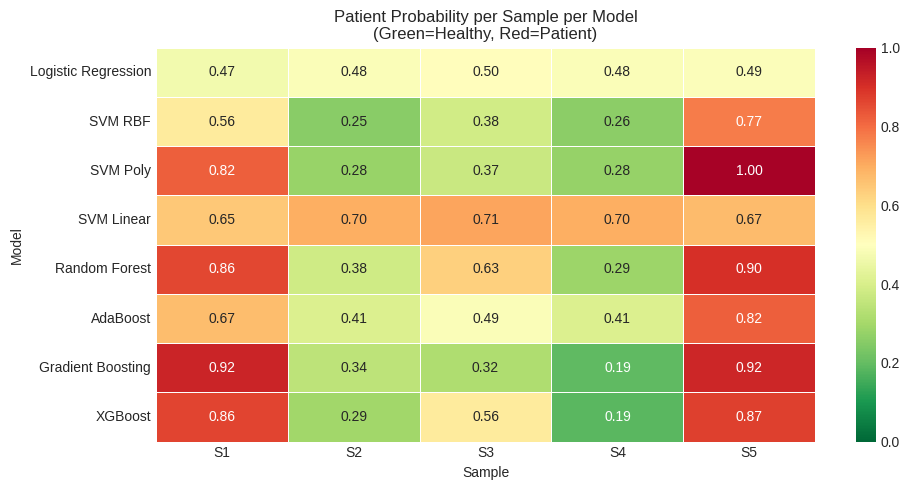

Sample Reference:
  S1: Older male, elevated bilirubin and enzymes — likely patient
  S2: Young female, normal values across the board — likely healthy
  S3: Middle-aged male, borderline values — uncertain
  S4: Young female, low-normal values — likely healthy
  S5: Elderly male, severely elevated bilirubin and enzymes — likely patient


In [34]:
# ── Visual: probability heatmap across all samples and models
fig, ax = plt.subplots(figsize=(10, 5))

prob_matrix = prob_df.set_index('Model').values.astype(float)
sns.heatmap(prob_matrix,
            annot=True, fmt='.2f',
            xticklabels=[f'S{i+1}' for i in range(len(samples))],
            yticklabels=prob_df['Model'].tolist(),
            cmap='RdYlGn_r',
            vmin=0, vmax=1,
            linewidths=0.5,
            ax=ax)

ax.set_title('Patient Probability per Sample per Model\n(Green=Healthy, Red=Patient)', fontsize=12)
ax.set_xlabel('Sample')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/15_sample_prediction_heatmap.png', dpi=150)
plt.show()

# Print sample details for reference
print('Sample Reference:')
for i, desc in enumerate(descriptions):
    print(f'  S{i+1}: {desc}')